# ML Modeling Phase

In this project, we will apply supervised machine learning techniques to our dataset containing daily caffeine intake, sleep metrics (Deep, Light, REM, Total), and productivity durations.

### Goal
Our goal is to solve a predictive regression task:

1. **Regression Task:** 
   Predict the **Productivity (minutes)** as a continuous variable based on physiological (caffeine intake) and behavioral inputs (sleep patterns).

---

### Feature Engineering Plan

In order to prepare the dataset for machine learning methods, we will:

- **Select Features**  
  Extract relevant columns (`Caffeine`, `Total Sleep`, `REM`, `Light`, `Deep`) from the raw datasheet.

- **Clean and Preprocess**  
  - Remove unnecessary strings such as "mg" and convert them to numeric.
  - Apply **Standard Scaling** to normalize features to be able to compare them with each other.

---

### Model Plan

We will train and compare two regression models:

- **Linear Regression**
- **Random Forest Regressor**

Each model will be evaluated using:

- **MSE (Mean Squared Error)**
- **RMSE (Root Mean Squared Error)**

We will also use **K-Fold Cross-Validation** to ensure our results are robust given our limited dataset size.

## Install Libraries

In [4]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Read Datasets

In [5]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('datasheet.csv')

## Data Preprocessing and Extraction

To prepare the data for machine learning, we select specific columns by index to ensure accuracy and clean the string-formatted data into numerical values.

In this part we:
- Extracted sleep patterns and caffeine data.
- Cleaned "mg" strings from the Caffeine column.
- Handled empty rows with missing values.

In [6]:
data = pd.DataFrame()

try:
    # Extracting columns using integer location (iloc)
    # Indices based on datasheet structure
    data['TotalSleep_min'] = df.iloc[:, 3]
    data['REM_min'] = df.iloc[:, 5]
    data['Light_min'] = df.iloc[:, 7]
    data['Deep_min'] = df.iloc[:, 9]
    data['Caffeine_mg'] = df.iloc[:, 10]
    data['Productivity_min'] = df.iloc[:, 13]
    
    # Clean 'Caffeine_mg' column (remove ' mg' and convert to numeric)
    data['Caffeine_mg'] = data['Caffeine_mg'].astype(str).str.replace('mg', '', case=False).str.strip()
    data['Caffeine_mg'] = pd.to_numeric(data['Caffeine_mg'])

    # Drop any rows with missing values
    data = data.dropna()
    
    # Show result stats similar to friend's notebook
    print("Cleaned DataFrame Shape:", data.shape)
    print("Total columns:", len(data.columns))
    print("\nAll column names:\n")
    for col in data.columns:
        print("-", col)

except Exception as e:
    print(f"An error occurred during data processing: {e}")

Cleaned DataFrame Shape: (25, 6)
Total columns: 6

All column names:

- TotalSleep_min
- REM_min
- Light_min
- Deep_min
- Caffeine_mg
- Productivity_min


## Quick Data Check

To prepare for modeling, we first validate the data types of each feature and check for any gaps in the data that need addressing.

In [7]:
# Check data types and missing values
data.info()

# Count missing values per column
missing = data.isnull().sum()
print("\n Missing Values Summary:")
print(missing[missing > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   TotalSleep_min    25 non-null     int64
 1   REM_min           25 non-null     int64
 2   Light_min         25 non-null     int64
 3   Deep_min          25 non-null     int64
 4   Caffeine_mg       25 non-null     int64
 5   Productivity_min  25 non-null     int64
dtypes: int64(6)
memory usage: 1.3 KB

 Missing Values Summary:
Series([], dtype: int64)


## Data Preview

We test what data random rows contain to inspect whether the data is successfully and correctly extracted.

In [ ]:
# See 5 random rows
display(data.sample(5))

# Print summary statistics
print(data.describe())

,TotalSleep_min,REM_min,Light_min,Deep_min,Caffeine_mg,Productivity_min
4,421,88,191,75,75,120
12,446,107,283,56,135,200
24,468,142,283,43,135,240
19,464,89,326,49,410,360
18,418,76,283,59,0,105


       TotalSleep_min     REM_min   Light_min   Deep_min  Caffeine_mg  \
count        25.00000   25.000000   25.000000  25.000000    25.000000   
mean        438.60000   95.280000  288.680000  51.560000   114.760000   
std          52.60545   23.129202   42.891064  12.662543   113.518457   
min         324.00000   49.000000  191.000000  33.000000     0.000000   
25%         412.00000   85.000000  271.000000  39.000000    25.000000   
50%         450.00000   95.000000  290.000000  52.000000   135.000000   
75%         468.00000  107.000000  317.000000  59.000000   135.000000   
max         557.00000  145.000000  379.000000  75.000000   410.000000   

       Productivity_min  
count         25.000000  
mean         196.600000  
std          100.485488  
min           60.000000  
25%          105.000000  
50%          180.000000  
75%          300.000000  
max          360.000000  


## Normalizing Features and Train/Test Split

We will split the dataset into training (80%) and testing (20%) sets. 

We'll also scale the features to normalize them.

In [34]:
# Define Features (X) and Target (y)
X = data[['Caffeine_mg', 'TotalSleep_min', 'REM_min', 'Light_min', 'Deep_min']]
y = data['Productivity_min']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=1881)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 20 samples
Testing set size: 5 samples


## Training The Models

In this part we will train both models.

In [35]:
# Initialize models
LR_model = LinearRegression()
RF_model = RandomForestRegressor(n_estimators=100, random_state=1881)

# Train the models
LR_model.fit(X_train, y_train)
RF_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## Model Evaluation

We evaluate the models using **MSE** and **RMSE**, as well as **K-Fold Cross-Validation** to get a reliable estimate of model performance on our relatively small dataset.

In [38]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    # Calculate the MSE and RMSE
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return {'Model': name, 'MSE': mse, 'RMSE': rmse}

results = []
results.append(evaluate_model(LR_model, X_test, y_test, "Linear Regression"))
results.append(evaluate_model(RF_model, X_test, y_test, "Random Forest"))

# Create comparison table for the MSE and RMSE in the test set.
results_df = pd.DataFrame(results)
print("Test Set Performance Comparison:")
display(results_df.round(3))

Test Set Performance Comparison:


,Model,MSE,RMSE
0,Linear Regression,2869.031,53.563
1,Random Forest,5240.279,72.390


### K-Fold Cross-Validation

Since our dataset is small, a single train-test split might be unstable. We use **5-Fold Cross-Validation** to train and test the model 5 times on different pieces of the data, to provide a better estimate of the RMSE. We have chosen the k as 5 due to 80%-20% train-test split.

In [51]:
# Define K-Fold Cross Validator
kf = KFold(n_splits=10, shuffle=True, random_state=1881)

def cross_validate_rmse(model, X, y, name):
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    return "{}: Average RMSE = {:.2f} (+/- {:.2f})".format(name, rmse_scores.mean(), rmse_scores.std())

print("Cross-Validation Results:")
print(cross_validate_rmse(LR_model, X_scaled_df, y, "Linear Regression"))
print(cross_validate_rmse(RF_model, X_scaled_df, y, "Random Forest    "))

Cross-Validation Results:
Linear Regression: Average RMSE = 75.65 (+/- 79.44)
Random Forest    : Average RMSE = 64.38 (+/- 37.12)


## Feature Importance

Now we will analyze which features have the strongest relationship with productivity.

In [55]:
# Linear Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': LR_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Random Forest Feature Importance
RF_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RF_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Linear Regression Coefficients:")
display(coef_df)

print("\nRandom Forest Feature Importance:")
display(RF_imp_df)

Linear Regression Coefficients:


,Feature,Coefficient
0,Caffeine_mg,57.843547
2,REM_min,21.684030
1,TotalSleep_min,19.107381
3,Light_min,14.842672
4,Deep_min,-10.503414



Random Forest Feature Importance:


,Feature,Importance
0,Caffeine_mg,0.516154
2,REM_min,0.193605
3,Light_min,0.170234
1,TotalSleep_min,0.088819
4,Deep_min,0.031188


As we can see from the both results, the importance of **Caffeine_mg** is the highest, suggesting that it has the most significant impact on productivity.

## Visualization

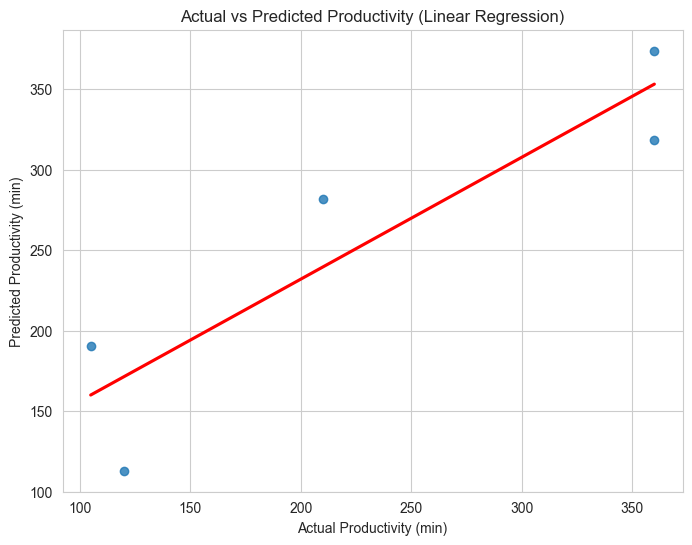

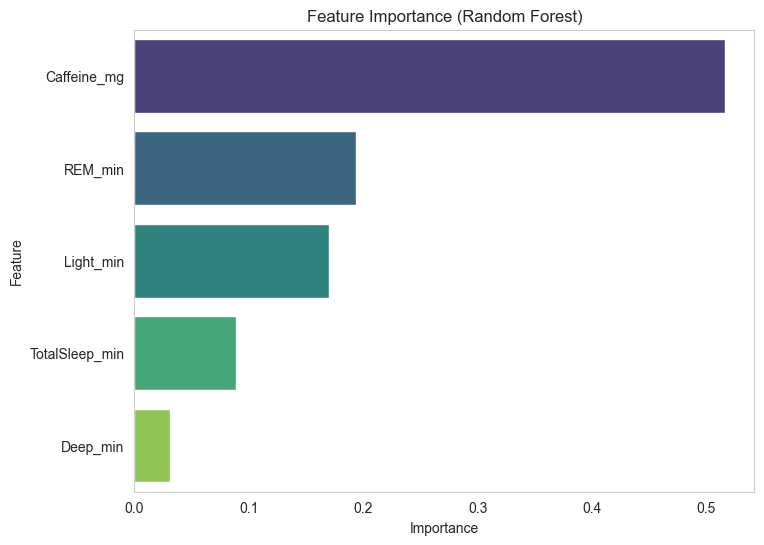

In [57]:
# 1. Predicted vs Actual Plot (Linear Regression)
y_pred_LR = LR_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred_LR, ci=None, line_kws={"color": "red"})
plt.title('Actual vs Predicted Productivity (Linear Regression)')
plt.xlabel('Actual Productivity (min)')
plt.ylabel('Predicted Productivity (min)')
plt.show()

# 2. Feature Importance Bar Plot (Random Forest)
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=RF_imp_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.grid(False)
plt.show()

The linear regression plot remained relatively empty due to our small dataset size and our test split.

## General Analysis

### Model Performance
We compared Linear Regression and Random Forest models using MSE and RMSE metrics. We also employed K-Fold Cross-Validation to validate the stability of our models on our small dataset.

### Conclusion and Future Work
This project established a pipeline to predict productivity from sleep and caffeine metrics. Future work should focus on **increasing the dataset size** to improve model stability and generalizability.